   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 3.3 MB/s eta 0:00:00


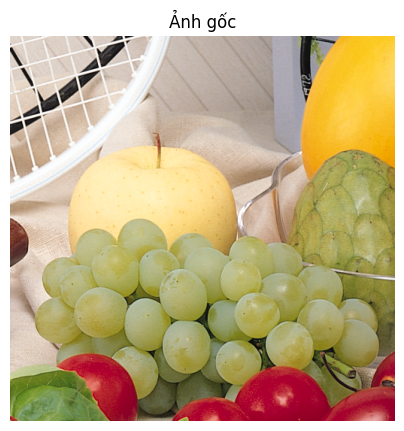

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

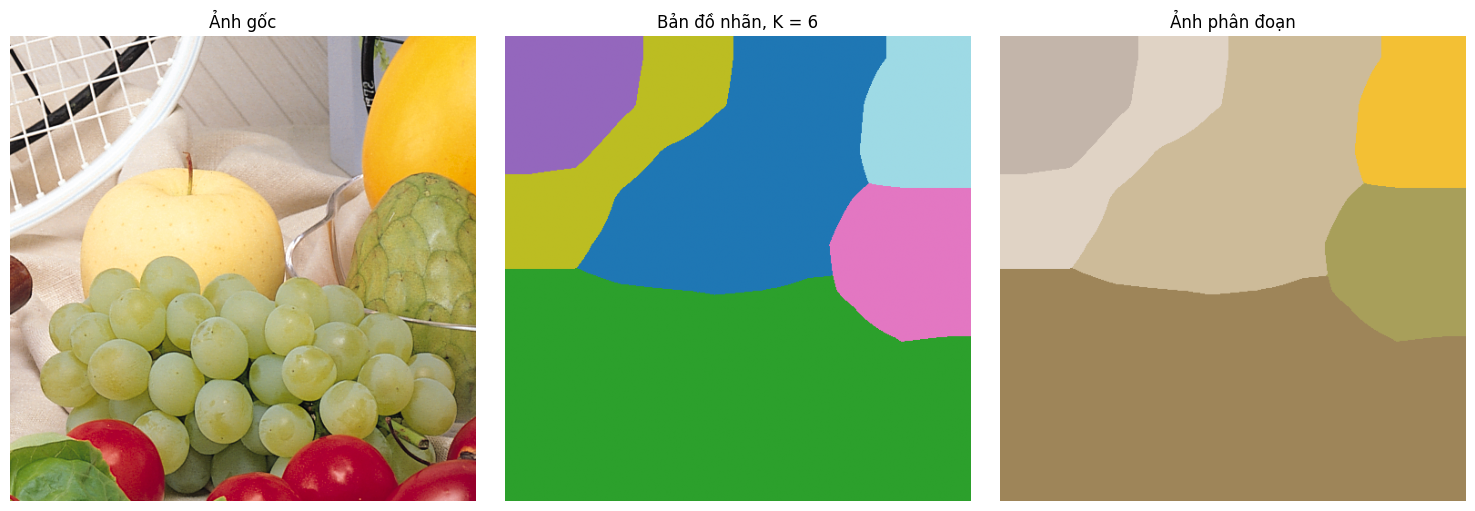

Kích thước ảnh gốc: (512, 512, 3)
Kích thước bản đồ nhãn: (512, 512)
Số nhãn phân đoạn: 6
Các nhãn xuất hiện: [0 1 2 3 4 5]
Đã lưu file:
/content/unetpp_kmeans_label.png
/content/unetpp_kmeans_segmented.png
Kiểm tra hoàn tất: chương trình chạy đúng.


In [1]:
# ============================================================
# GIÁO TRÌNH: THỊ GIÁC MÁY: TỪ XỬ LÝ ẢNH ĐẾN HỌC SÂU
# BÀI CODE MINH HỌA: Phân đoạn ảnh bằng đặc trưng encoder U-Net++ và K-means
# Chương/Mục liên quan: Chương 8 - Mô hình học sâu cho phân đoạn ảnh
# ============================================================

# ============================================================
# MÔ TẢ
# ============================================================

# Mục đích:
# - Minh họa cách dùng encoder pretrained ImageNet của U-Net++ để trích xuất đặc trưng ảnh.
# - Kết hợp đặc trưng học sâu, màu sắc và vị trí không gian của pixel.
# - Dùng K-means để tạo bản đồ phân đoạn ảnh không giám sát.

# Sau khi chạy code, người học cần:
# 1. Quan sát được ảnh gốc, bản đồ nhãn và ảnh phân đoạn.
# 2. Hiểu vai trò của đặc trưng học sâu trong phân đoạn ảnh.
# 3. Hiểu rằng K-means gom các pixel có vector đặc trưng gần nhau vào cùng một segment.

# Input:
# - Dữ liệu đầu vào: ảnh fruits.png từ GitHub
# - Kiểu dữ liệu: ảnh màu RGB

# Output:
# - Ảnh gốc
# - Bản đồ nhãn phân đoạn
# - Ảnh phân đoạn bằng màu trung bình của từng segment
# - Hai file kết quả được lưu trong /content/

# Lưu ý:
# Đoạn code này được xây dựng với sự hỗ trợ của công cụ AI.
# Giảng viên đã đọc, kiểm tra và hiệu chỉnh nhằm bảo đảm tính chính xác,
# tính sư phạm và sự phù hợp với nội dung lý thuyết trong giáo trình.

# ============================================================
# 1. CÀI ĐẶT VÀ IMPORT THƯ VIỆN
# ============================================================

!pip -q install segmentation-models-pytorch opencv-python pillow matplotlib scikit-learn

import cv2
import torch
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp

from PIL import Image
from sklearn.cluster import KMeans
from torchvision import transforms

# ============================================================
# 2. TẢI DỮ LIỆU ĐẦU VÀO
# ============================================================

img_url = "https://github.com/lthavnu/cv-book/raw/main/images/fruits.png"
img_path = "/content/fruits.png"

urllib.request.urlretrieve(img_url, img_path)

image = Image.open(img_path).convert("RGB")
image_np = np.array(image)

H, W = image_np.shape[:2]

# ============================================================
# 3. HIỂN THỊ ẢNH ĐẦU VÀO
# ============================================================

plt.figure(figsize=(5, 5))
plt.imshow(image_np)
plt.title("Ảnh gốc")
plt.axis("off")
plt.show()

# ============================================================
# 4. XỬ LÝ CHÍNH
# ============================================================

# ------------------------------------------------------------
# 4.1. Load U-Net++ với encoder pretrained ImageNet
# ------------------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = smp.UnetPlusPlus(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=6,
    activation=None
)

model.to(device)
model.eval()

# ------------------------------------------------------------
# 4.2. Tiền xử lý ảnh theo chuẩn ImageNet
# ------------------------------------------------------------

preprocess = transforms.Compose([
    transforms.Resize((320, 320)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])

x = preprocess(image).unsqueeze(0).to(device)

# ------------------------------------------------------------
# 4.3. Trích xuất đặc trưng từ encoder pretrained
# ------------------------------------------------------------

with torch.no_grad():
    features = model.encoder(x)

feat = features[-1]

feat = torch.nn.functional.interpolate(
    feat,
    size=(H, W),
    mode="bilinear",
    align_corners=False
)

feat = feat.squeeze(0).permute(1, 2, 0).cpu().numpy()

# ------------------------------------------------------------
# 4.4. Kết hợp đặc trưng học sâu, màu sắc và vị trí
# ------------------------------------------------------------

rgb = image_np.astype(np.float32) / 255.0

lab = cv2.cvtColor(image_np, cv2.COLOR_RGB2LAB).astype(np.float32)
lab[..., 0] /= 100.0
lab[..., 1:] = (lab[..., 1:] - 128.0) / 128.0

yy, xx = np.meshgrid(
    np.linspace(0, 1, H),
    np.linspace(0, 1, W),
    indexing="ij"
)

pos = np.stack([xx, yy], axis=-1)

X = np.concatenate([
    feat * 0.8,
    lab  * 1.5,
    pos  * 0.5
], axis=-1)

X = X.reshape(-1, X.shape[-1])

# ------------------------------------------------------------
# 4.5. Gom cụm K-means để tạo các segment
# ------------------------------------------------------------

K = 6

kmeans = KMeans(
    n_clusters=K,
    random_state=0,
    n_init=10
)

labels = kmeans.fit_predict(X)
seg_map = labels.reshape(H, W)

# ------------------------------------------------------------
# 4.6. Tạo ảnh phân đoạn bằng màu trung bình từng segment
# ------------------------------------------------------------

seg_color = np.zeros_like(image_np)

for k in range(K):
    mask = seg_map == k
    if np.any(mask):
        mean_color = image_np[mask].mean(axis=0)
        seg_color[mask] = mean_color

seg_color = cv2.medianBlur(seg_color, 5)

# ============================================================
# 5. HIỂN THỊ KẾT QUẢ
# ============================================================

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image_np)
plt.title("Ảnh gốc")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(seg_map, cmap="tab20")
plt.title(f"Bản đồ nhãn, K = {K}")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(seg_color)
plt.title("Ảnh phân đoạn")
plt.axis("off")

plt.tight_layout()
plt.show()

# ============================================================
# 6. KIỂM TRA KẾT QUẢ
# ============================================================

cv2.imwrite("/content/unetpp_kmeans_label.png", seg_map.astype(np.uint8))

cv2.imwrite(
    "/content/unetpp_kmeans_segmented.png",
    cv2.cvtColor(seg_color, cv2.COLOR_RGB2BGR)
)

print("Kích thước ảnh gốc:", image_np.shape)
print("Kích thước bản đồ nhãn:", seg_map.shape)
print("Số nhãn phân đoạn:", len(np.unique(seg_map)))
print("Các nhãn xuất hiện:", np.unique(seg_map))
print("Đã lưu file:")
print("/content/unetpp_kmeans_label.png")
print("/content/unetpp_kmeans_segmented.png")

assert image_np.shape[:2] == seg_map.shape
assert len(np.unique(seg_map)) == K
assert seg_color.shape == image_np.shape

print("Kiểm tra hoàn tất: chương trình chạy đúng.")

# ============================================================
# 7. GỢI Ý THỬ NGHIỆM CHO NGƯỜI HỌC
# ============================================================

# 1. Thay đổi K = 4, 5, 8 để quan sát số vùng phân đoạn thay đổi.
# 2. Thay đổi trọng số feat * 0.8 để tăng hoặc giảm vai trò của đặc trưng học sâu.
# 3. Thay đổi trọng số lab * 1.5 hoặc pos * 0.5 để quan sát ảnh hưởng của màu sắc và vị trí.